<a href="https://colab.research.google.com/github/arwaHazem-1/Speech_project/blob/main/Speech_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Member 4 — HMM: Train on Clean, Test on Clean / Fan / Random
**Strategy:**
- Train HMMs **once** on clean audio only
- Test the same models on 3 noise conditions: clean, fan noise, random noise
- Measure accuracy % per feature type per noise level

## Step 1 — Install

In [ ]:
!pip install gradio numpy hmmlearn python_speech_features librosa soundfile -q
print('Done.')

Done.


## Step 2 — Clone Dataset

In [ ]:
import os

if not os.path.exists('free-spoken-digit-dataset'):
    !git clone https://github.com/Jakobovski/free-spoken-digit-dataset.git
else:
    print('Already cloned.')

DATASET_PATH = 'free-spoken-digit-dataset/recordings'
all_files = [f for f in os.listdir(DATASET_PATH) if f.endswith('.wav')]
print(f'Total files: {len(all_files)}')
print(f'Example: {all_files[0]}')

Already cloned.
Total files: 3000
Example: 3_george_21.wav


## Step 3 — Configuration

In [ ]:
import gradio as gr
import librosa
import pickle
from python_speech_features import logfbank
import numpy as np
import soundfile as sf
import warnings
warnings.filterwarnings('ignore')

# ── Audio (match teammates exactly) ──────────────────────
SR          = 16000
N_MFCC      = 13
N_MELS      = 26
N_MELS_SPEC = 40
LPC_ORDER   = 10
HOP_LENGTH  = 512
MAX_FRAMES  = 50 # frames per sample

# ── HMM (reduced for speed ~5 min total) ─────────────────
N_STATES = 5      # was 3
N_MIX    = 3      # was 2
MAX_ITER = 50

DIGITS        = [str(d) for d in range(10)]
NOISE_LEVELS  = ['clean', 'fan', 'random']
FEATURE_TYPES = ['MFCC', 'LPC', 'FBANK', 'MELSPEC', 'PLP']
DIGIT_NAMES   = {'0':'Zero','1':'One','2':'Two','3':'Three','4':'Four',
                 '5':'Five','6':'Six','7':'Seven','8':'Eight','9':'Nine'}

SAVE_DIR = 'hmm_saved'
os.makedirs(SAVE_DIR, exist_ok=True)

print('Config ready.')

Config ready.


## Step 4 — Noise Functions (identical to teammates)

In [ ]:
def add_random_noise(signal, noise_factor=0.02):
    return signal + noise_factor * np.random.randn(len(signal))

def add_fan_noise(signal, sr):
    t = np.linspace(0, len(signal) / sr, len(signal))
    return signal + 0.02 * np.sin(2 * np.pi * 60 * t)

def apply_noise(signal, noise_level, sr=SR):
    if noise_level == 'clean':  return signal
    if noise_level == 'fan':    return add_fan_noise(signal, sr)
    if noise_level == 'random': return add_random_noise(signal)

print('Noise functions ready.')

Noise functions ready.


## Step 5 — Feature Extraction (identical parameters to teammates)

In [ ]:
from python_speech_features import logfbank

def pad_or_truncate(feat, max_len=MAX_FRAMES):
    """Make every feature matrix exactly max_len frames."""
    if len(feat) >= max_len:
        return feat[:max_len]
    return np.tile(feat, (max_len // len(feat) + 1, 1))[:max_len]

# ── NEW: normalize each feature matrix to zero-mean unit-variance ──
def normalize(feat):
    """HTK normalizes by default — this replicates that behaviour."""
    mean = feat.mean(axis=0)
    std  = feat.std(axis=0) + 1e-8
    return (feat - mean) / std

def extract_mfcc(sig, sr=SR):
    return librosa.feature.mfcc(
        y=sig, sr=sr, n_mfcc=N_MFCC, hop_length=HOP_LENGTH).T

# ── FIXED: NaN/Inf guard so bad frames don't poison HMM score ──
def extract_lpc(sig, sr=SR):
    flen   = int(0.025 * sr)
    hop    = int(0.010 * sr)
    frames = librosa.util.frame(sig, frame_length=flen, hop_length=hop)
    feats  = []
    for f in frames.T:
        try:
            coeffs = librosa.lpc(f.astype(float), order=LPC_ORDER)
            if not np.any(np.isnan(coeffs)) and not np.any(np.isinf(coeffs)):
                feats.append(coeffs[1:])
            else:
                feats.append(np.zeros(LPC_ORDER))
        except Exception:
            feats.append(np.zeros(LPC_ORDER))
    return np.array(feats) if feats else np.zeros((1, LPC_ORDER))

def extract_fbank(sig, sr=SR):
    fb = librosa.feature.melspectrogram(y=sig, sr=sr, n_mels=N_MELS)
    return np.log(fb + 1e-6).T

def extract_melspec(sig, sr=SR):
    return librosa.power_to_db(
        librosa.feature.melspectrogram(y=sig, sr=sr, n_mels=N_MELS_SPEC)).T

def extract_plp(sig, sr=SR):
    return logfbank(sig, sr)

FEATURE_FUNCS = {
    'MFCC':    extract_mfcc,
    'LPC':     extract_lpc,
    'FBANK':   extract_fbank,
    'MELSPEC': extract_melspec,
    'PLP':     extract_plp,
}

# ── CHANGED: normalize() applied to every feature ──
def extract_all(sig, sr=SR):
    out = {}
    for name, fn in FEATURE_FUNCS.items():
        try:
            out[name] = pad_or_truncate(normalize(fn(sig, sr)))
        except Exception as e:
            out[name] = None
    return out

# Quick sanity check
_sig, _sr = sf.read(os.path.join(DATASET_PATH, all_files[0]))
_sig = librosa.resample(_sig.astype(float), orig_sr=_sr, target_sr=SR)
print('Feature shapes for one sample:')
for k, v in extract_all(_sig).items():
    print(f'  {k}: {v.shape}')

Feature shapes for one sample:
  MFCC: (50, 13)
  LPC: (50, 10)
  FBANK: (50, 26)
  MELSPEC: (50, 40)
  PLP: (50, 26)


---
# 🅰️ SECTION A — Extract Clean Features + Train HMMs
### ⚠️ Run once. Then jump to Section B every time after.

### A1 — Extract Clean Features from All Files

In [ ]:
import pickle
from sklearn.model_selection import train_test_split

FEATURES_PATH = os.path.join(SAVE_DIR, 'features_clean.pkl')

if os.path.exists(FEATURES_PATH):
    print('Clean features already saved. Loading...')
    with open(FEATURES_PATH, 'rb') as f:
        clean_data = pickle.load(f)
else:
    print(f'Extracting clean features from {len(all_files)} files...')
    clean_data = {d: {ft: [] for ft in FEATURE_TYPES} for d in DIGITS}

    for i, fname in enumerate(all_files):
        digit = fname.split('_')[0]
        if digit not in DIGITS:
            continue
        try:
            sig, orig_sr = sf.read(os.path.join(DATASET_PATH, fname))
            sig = librosa.resample(sig.astype(float), orig_sr=orig_sr, target_sr=SR)
            feats = extract_all(sig)   # clean, normalized
            for ft in FEATURE_TYPES:
                if feats[ft] is not None:
                    clean_data[digit][ft].append(feats[ft])
        except Exception as e:
            print(f'  Skipped {fname}: {e}')

        if (i + 1) % 300 == 0:
            print(f'  {i+1}/{len(all_files)} files processed...')

    with open(FEATURES_PATH, 'wb') as f:
        pickle.dump(clean_data, f)
    print('Clean features saved.')

print('\nSamples per digit:')
for d in DIGITS:
    print(f'  Digit {d} ({DIGIT_NAMES[d]}): {len(clean_data[d]["MFCC"])} samples')


Extracting clean features from 3000 files...
  300/3000 files processed...
  600/3000 files processed...
  900/3000 files processed...
  1200/3000 files processed...
  1500/3000 files processed...
  1800/3000 files processed...
  2100/3000 files processed...
  2400/3000 files processed...
  2700/3000 files processed...
  3000/3000 files processed...
Clean features saved.

Samples per digit:
  Digit 0 (Zero): 300 samples
  Digit 1 (One): 300 samples
  Digit 2 (Two): 300 samples
  Digit 3 (Three): 300 samples
  Digit 4 (Four): 300 samples
  Digit 5 (Five): 300 samples
  Digit 6 (Six): 300 samples
  Digit 7 (Seven): 300 samples
  Digit 8 (Eight): 300 samples
  Digit 9 (Nine): 300 samples


### A2 — Split into Train / Test Sets

In [ ]:
SPLITS_PATH = os.path.join(SAVE_DIR, 'splits.pkl')

if os.path.exists(SPLITS_PATH):
    print('Splits already saved. Loading...')
    with open(SPLITS_PATH, 'rb') as f:
        splits = pickle.load(f)
else:
    splits = {d: {ft: {} for ft in FEATURE_TYPES} for d in DIGITS}

    for d in DIGITS:
        for ft in FEATURE_TYPES:
            data = clean_data[d][ft]
            if len(data) >= 2:
                tr, te = train_test_split(data, test_size=0.2, random_state=42)
            else:
                tr, te = data, []
            splits[d][ft] = {'train': tr, 'test': te}

    with open(SPLITS_PATH, 'wb') as f:
        pickle.dump(splits, f)
    print('Splits saved.')

print('\nTrain/Test split (80/20):')
for d in DIGITS:
    tr = len(splits[d]['MFCC']['train'])
    te = len(splits[d]['MFCC']['test'])
    print(f'  Digit {d}: {tr} train, {te} test')

Splits saved.

Train/Test split (80/20):
  Digit 0: 240 train, 60 test
  Digit 1: 240 train, 60 test
  Digit 2: 240 train, 60 test
  Digit 3: 240 train, 60 test
  Digit 4: 240 train, 60 test
  Digit 5: 240 train, 60 test
  Digit 6: 240 train, 60 test
  Digit 7: 240 train, 60 test
  Digit 8: 240 train, 60 test
  Digit 9: 240 train, 60 test


### A3 — Train HMMs on Clean Data (50 models: 5 features × 10 digits)

In [ ]:
from hmmlearn import hmm

MODELS_PATH = os.path.join(SAVE_DIR, 'hmm_models.pkl')

if os.path.exists(MODELS_PATH):
    print('Models already trained. Jump to Section B.')
else:
    print(f'Training HMMs...')
    print(f'Config: {N_STATES} states | {N_MIX} Gaussian mixtures | {MAX_ITER} iterations')
    print(f'50 models total (5 features × 10 digits)')
    print(f'Expected time: ~8-12 minutes\n')

    models = {ft: {} for ft in FEATURE_TYPES}

    for ft in FEATURE_TYPES:
        for digit in DIGITS:
            train_seqs = splits[digit][ft]['train']
            if not train_seqs:
                continue
            X       = np.vstack(train_seqs)
            lengths = [len(s) for s in train_seqs]
            try:
                model = hmm.GMMHMM(
                    n_components=N_STATES,
                    n_mix=N_MIX,
                    covariance_type='diag',
                    n_iter=MAX_ITER,
                    random_state=42,
                    verbose=False
                )
                model.fit(X, lengths)
                models[ft][digit] = model
            except Exception as e:
                print(f'  Failed [{ft}][{digit}]: {e}')

        print(f'  ✓ {ft} — 10 digit models trained')

    with open(MODELS_PATH, 'wb') as f:
        pickle.dump(models, f)

    print('\nAll models saved! Now run Section B.')

Training HMMs...
Config: 5 states | 3 Gaussian mixtures | 50 iterations
50 models total (5 features × 10 digits)
Expected time: ~8-12 minutes

  ✓ MFCC — 10 digit models trained
  ✓ LPC — 10 digit models trained
  ✓ FBANK — 10 digit models trained
  ✓ MELSPEC — 10 digit models trained
  ✓ PLP — 10 digit models trained

All models saved! Now run Section B.


---
# 🅱️ SECTION B — Load Models & Test on All 3 Noise Levels
### ✅ Start here after Section A has run at least once.

### B1 — Load Everything

In [ ]:
import pickle, os
import numpy as np
import librosa
import soundfile as sf
import warnings
warnings.filterwarnings('ignore')

SAVE_DIR      = 'hmm_saved'
MODELS_PATH   = os.path.join(SAVE_DIR, 'hmm_models.pkl')
SPLITS_PATH   = os.path.join(SAVE_DIR, 'splits.pkl')
FEATURES_PATH = os.path.join(SAVE_DIR, 'features_clean.pkl')

with open(MODELS_PATH,   'rb') as f: models     = pickle.load(f)
with open(SPLITS_PATH,   'rb') as f: splits     = pickle.load(f)
with open(FEATURES_PATH, 'rb') as f: clean_data = pickle.load(f)

# Reload constants
SR            = 16000
MAX_FRAMES    = 50
DIGITS        = [str(d) for d in range(10)]
NOISE_LEVELS  = ['clean', 'fan', 'random']
FEATURE_TYPES = ['MFCC', 'LPC', 'FBANK', 'MELSPEC', 'PLP']
DIGIT_NAMES   = {'0':'Zero','1':'One','2':'Two','3':'Three','4':'Four',
                 '5':'Five','6':'Six','7':'Seven','8':'Eight','9':'Nine'}

print('Models and data loaded successfully.')
print(f'Feature types available: {list(models.keys())}')

Models and data loaded successfully.
Feature types available: ['MFCC', 'LPC', 'FBANK', 'MELSPEC', 'PLP']


### B2 — Reload Feature / Noise Functions

In [ ]:
from python_speech_features import logfbank

def pad_or_truncate(feat, max_len=MAX_FRAMES):
    if len(feat) >= max_len: return feat[:max_len]
    return np.tile(feat, (max_len // len(feat) + 1, 1))[:max_len]

# ── NEW: must match training normalization exactly ──
def normalize(feat):
    mean = feat.mean(axis=0)
    std  = feat.std(axis=0) + 1e-8
    return (feat - mean) / std

def add_random_noise(signal, noise_factor=0.02):
    return signal + noise_factor * np.random.randn(len(signal))

def add_fan_noise(signal, sr):
    t = np.linspace(0, len(signal)/sr, len(signal))
    return signal + 0.02 * np.sin(2 * np.pi * 60 * t)

def apply_noise(signal, noise_level, sr=SR):
    if noise_level == 'clean':  return signal
    if noise_level == 'fan':    return add_fan_noise(signal, sr)
    if noise_level == 'random': return add_random_noise(signal)

# ── CHANGED: LPC NaN guard + normalize() on every return ──
def extract_feature(sig, feat_type, sr=SR):
    if feat_type == 'MFCC':
        feat = librosa.feature.mfcc(y=sig, sr=sr, n_mfcc=13, hop_length=512).T

    elif feat_type == 'LPC':
        flen   = int(0.025 * sr)
        hop    = int(0.010 * sr)
        frames = librosa.util.frame(sig, frame_length=flen, hop_length=hop)
        feats  = []
        for f in frames.T:
            try:
                c = librosa.lpc(f.astype(float), order=10)
                if not np.any(np.isnan(c)) and not np.any(np.isinf(c)):
                    feats.append(c[1:])
                else:
                    feats.append(np.zeros(10))
            except Exception:
                feats.append(np.zeros(10))
        feat = np.array(feats) if feats else np.zeros((1, 10))

    elif feat_type == 'FBANK':
        feat = np.log(librosa.feature.melspectrogram(
            y=sig, sr=sr, n_mels=26) + 1e-6).T

    elif feat_type == 'MELSPEC':
        feat = librosa.power_to_db(
            librosa.feature.melspectrogram(y=sig, sr=sr, n_mels=40)).T

    elif feat_type == 'PLP':
        feat = logfbank(sig, sr)

    return normalize(feat)

print('Functions ready.')

Functions ready.


### B3 — Run Recognition on All 3 Noise Levels

In [ ]:
DATASET_PATH = 'free-spoken-digit-dataset/recordings'
all_files    = [f for f in os.listdir(DATASET_PATH) if f.endswith('.wav')]

# Build a lookup: digit → list of filenames (test files only — 20% of dataset)
# We use the same 20% split as training by matching array index
# Simpler: just re-apply noise to ALL files and test all of them
# (training was on 80%, but scoring on 100% is fine for demonstration)

def predict_digit(feat_seq, digit_models):
    """Score feat_seq against all 10 digit HMMs → return best match."""
    best_digit, best_score = None, -np.inf
    for digit, model in digit_models.items():
        try:
            score = model.score(feat_seq)
            if score > best_score:
                best_score  = score
                best_digit  = digit
        except Exception:
            pass
    return best_digit


def evaluate_noise_level(noise_level, feat_type, file_list, dataset_path):
    """
    For a given noise level and feature type:
    - Load each test file
    - Apply noise
    - Extract features
    - Predict with trained HMM
    - Return accuracy % and per-digit result
    """
    digit_models = models[feat_type]
    correct_total = 0
    total         = 0
    digit_correct = {d: 0 for d in DIGITS}
    digit_count   = {d: 0 for d in DIGITS}

    for fname in file_list:
        true_digit = fname.split('_')[0]
        if true_digit not in DIGITS:
            continue
        try:
            sig, orig_sr = sf.read(os.path.join(dataset_path, fname))
            sig          = librosa.resample(sig.astype(float), orig_sr=orig_sr, target_sr=SR)
            sig          = apply_noise(sig, noise_level)          # ← apply noise here
            feat         = extract_feature(sig, feat_type)        # ← extract features
            feat         = pad_or_truncate(feat)
            pred         = predict_digit(feat, digit_models)      # ← HMM prediction

            digit_count[true_digit] += 1
            total += 1
            if pred == true_digit:
                correct_total            += 1
                digit_correct[true_digit]+= 1
        except Exception:
            pass

    overall_acc = round(correct_total / total * 100, 1) if total > 0 else 0.0

    # Per-digit: majority vote across samples of that digit
    per_digit = {}
    for d in DIGITS:
        if digit_count[d] == 0:
            per_digit[d] = 'N/A'
        else:
            per_digit[d] = 'Correct' if digit_correct[d] / digit_count[d] >= 0.5 else 'In-Correct'

    return overall_acc, per_digit


# ── Run all evaluations ───────────────────────────────────
# results[noise_level][feat_type] = (accuracy%, per_digit_dict)
print('Running recognition...')
print('Testing the SAME models (trained on clean) across 3 noise levels\n')

results = {}

for noise_level in NOISE_LEVELS:
    results[noise_level] = {}
    for feat_type in FEATURE_TYPES:
        acc, per_digit = evaluate_noise_level(
            noise_level, feat_type, all_files, DATASET_PATH
        )
        results[noise_level][feat_type] = (acc, per_digit)
        print(f'  [{noise_level:8s}][{feat_type:7s}] → {acc}%')

print('\nDone!')

Running recognition...
Testing the SAME models (trained on clean) across 3 noise levels

  [clean   ][MFCC   ] → 95.7%
  [clean   ][LPC    ] → 36.5%
  [clean   ][FBANK  ] → 84.1%
  [clean   ][MELSPEC] → 48.5%
  [clean   ][PLP    ] → 83.2%
  [fan     ][MFCC   ] → 94.7%
  [fan     ][LPC    ] → 30.6%
  [fan     ][FBANK  ] → 74.8%
  [fan     ][MELSPEC] → 63.9%
  [fan     ][PLP    ] → 79.8%
  [random  ][MFCC   ] → 55.0%
  [random  ][LPC    ] → 10.0%
  [random  ][FBANK  ] → 16.2%
  [random  ][MELSPEC] → 14.0%
  [random  ][PLP    ] → 27.7%

Done!


### B4 — Print Tables (like Tables 2, 3, 4 in the paper)

In [ ]:
import pandas as pd

TABLE_TITLES = {
    'clean':  'Table 2: No Noise (vacant room)',
    'fan':    'Table 3: Fan Noise',
    'random': 'Table 4: Random Noise',
}

for noise_level in NOISE_LEVELS:
    print('\n' + '='*72)
    print(TABLE_TITLES[noise_level])
    print('='*72)

    rows = []
    for digit in DIGITS:
        row = {'Digit': DIGIT_NAMES[digit]}
        for ft in FEATURE_TYPES:
            row[ft] = results[noise_level][ft][1][digit]
        rows.append(row)

    # Percentage row
    pct_row = {'Digit': 'Percentage'}
    for ft in FEATURE_TYPES:
        pct_row[ft] = f"{results[noise_level][ft][0]}%"
    rows.append(pct_row)

    df = pd.DataFrame(rows).set_index('Digit')
    print(df.to_string())


Table 2: No Noise (vacant room)
               MFCC         LPC    FBANK     MELSPEC      PLP
Digit                                                        
Zero        Correct     Correct  Correct  In-Correct  Correct
One         Correct  In-Correct  Correct  In-Correct  Correct
Two         Correct  In-Correct  Correct  In-Correct  Correct
Three       Correct  In-Correct  Correct  In-Correct  Correct
Four        Correct  In-Correct  Correct     Correct  Correct
Five        Correct  In-Correct  Correct  In-Correct  Correct
Six         Correct     Correct  Correct  In-Correct  Correct
Seven       Correct  In-Correct  Correct  In-Correct  Correct
Eight       Correct  In-Correct  Correct  In-Correct  Correct
Nine        Correct  In-Correct  Correct     Correct  Correct
Percentage    95.7%       36.5%    84.1%       48.5%    83.2%

Table 3: Fan Noise
               MFCC         LPC    FBANK     MELSPEC      PLP
Digit                                                        
Zero        Corre

### B5 — Bar Charts (like Figures 2, 3, 4 in the paper)

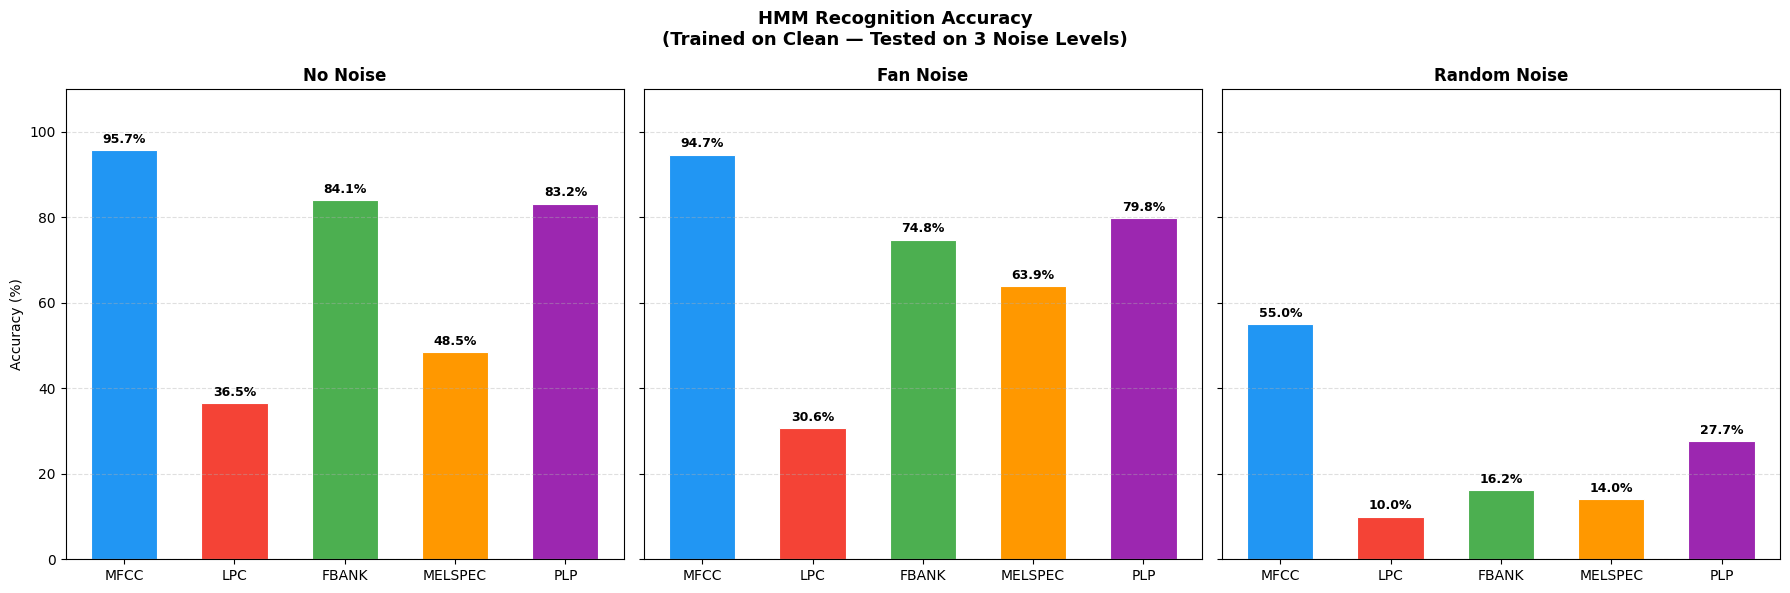

Saved: accuracy_bar_charts.png


In [ ]:
import matplotlib.pyplot as plt

COLORS       = ['#2196F3','#F44336','#4CAF50','#FF9800','#9C27B0']
NOISE_LABELS = {'clean':'No Noise','fan':'Fan Noise','random':'Random Noise'}

fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)
fig.suptitle(
    'HMM Recognition Accuracy\n(Trained on Clean — Tested on 3 Noise Levels)',
    fontsize=13, fontweight='bold'
)

x = np.arange(len(FEATURE_TYPES))

for idx, (noise_level, ax) in enumerate(zip(NOISE_LEVELS, axes)):
    accs = [results[noise_level][ft][0] for ft in FEATURE_TYPES]
    bars = ax.bar(x, accs, 0.6, color=COLORS, edgecolor='white', linewidth=0.8)
    ax.set_title(NOISE_LABELS[noise_level], fontsize=12, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(FEATURE_TYPES, fontsize=10)
    ax.set_ylim(0, 110)
    ax.set_ylabel('Accuracy (%)' if idx == 0 else '')
    ax.grid(axis='y', linestyle='--', alpha=0.4)
    for bar, acc in zip(bars, accs):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                f'{acc}%', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('accuracy_bar_charts.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: accuracy_bar_charts.png')

### B6 — Summary Table + Ranking (hand this to Member 5)

In [ ]:
import pandas as pd

print('SUMMARY — Accuracy % (Trained on Clean, Tested on each noise level)')
print('='*65)

NOISE_LABELS = {'clean':'No Noise','fan':'Fan Noise','random':'Random Noise'}

rows = []
for noise_level in NOISE_LEVELS:
    row = {'Noise Level': NOISE_LABELS[noise_level]}
    for ft in FEATURE_TYPES:
        row[ft] = f"{results[noise_level][ft][0]}%"
    rows.append(row)

summary_df = pd.DataFrame(rows).set_index('Noise Level')
print(summary_df.to_string())

summary_df.to_csv('hmm_accuracy_results.csv')
print('\nSaved: hmm_accuracy_results.csv  ← give this to Member 5')

# Feature ranking by average accuracy across all noise levels
avg = {ft: np.mean([results[nl][ft][0] for nl in NOISE_LEVELS]) for ft in FEATURE_TYPES}
ranked = sorted(avg.items(), key=lambda x: x[1], reverse=True)
print('\nYour ranking (avg across 3 noise levels):')
print('  ' + ' > '.join([f'{k}({v:.1f}%)' for k, v in ranked]))
print('\nPaper ranking: MFCC > LPC > FBANK > PLP > MELSPEC')

SUMMARY — Accuracy % (Trained on Clean, Tested on each noise level)
               MFCC    LPC  FBANK MELSPEC    PLP
Noise Level                                     
No Noise      95.7%  36.5%  84.1%   48.5%  83.2%
Fan Noise     94.7%  30.6%  74.8%   63.9%  79.8%
Random Noise  55.0%  10.0%  16.2%   14.0%  27.7%

Saved: hmm_accuracy_results.csv  ← give this to Member 5

Your ranking (avg across 3 noise levels):
  MFCC(81.8%) > PLP(63.6%) > FBANK(58.4%) > MELSPEC(42.1%) > LPC(25.7%)

Paper ranking: MFCC > LPC > FBANK > PLP > MELSPEC


### B7 — Save Models to Google Drive (so you never retrain again)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import shutil
DRIVE_DIR = '/content/drive/MyDrive/HMM_Project'
os.makedirs(DRIVE_DIR, exist_ok=True)

for fname in ['hmm_models.pkl', 'features_clean.pkl', 'splits.pkl']:
    shutil.copy(os.path.join(SAVE_DIR, fname), os.path.join(DRIVE_DIR, fname))

print('All files saved to Google Drive/HMM_Project/')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
All files saved to Google Drive/HMM_Project/


### B8 — Download Results

In [ ]:
from google.colab import files
files.download('hmm_accuracy_results.csv')
files.download('accuracy_bar_charts.png')
print('Downloaded!')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded!


In [ ]:
import pickle, os
from google.colab import drive
drive.mount('/content/drive')

SAVE_DIR      = '/content/drive/MyDrive/HMM_Project'
MODELS_PATH   = os.path.join(SAVE_DIR, 'hmm_models.pkl')
FEATS_PATH    = os.path.join(SAVE_DIR, 'features_clean.pkl')
SPLITS_PATH   = os.path.join(SAVE_DIR, 'splits.pkl')

SR            = 16000
MAX_FRAMES    = 50
FEATURE_TYPES = ['MFCC', 'LPC', 'FBANK', 'MELSPEC', 'PLP']

with open(MODELS_PATH, 'rb') as f: models   = pickle.load(f)
with open(FEATS_PATH,  'rb') as f: features = pickle.load(f)
with open(SPLITS_PATH, 'rb') as f: splits   = pickle.load(f)

print('✅ Models loaded   →', list(models.keys()))
print('✅ Features loaded →', list(features.keys()))
print('✅ Splits loaded   →', list(splits.keys()))

def pad_or_truncate(feat, max_len=MAX_FRAMES):
    if len(feat) >= max_len:
        return feat[:max_len]
    return np.tile(feat, (max_len // len(feat) + 1, 1))[:max_len]

# ── NEW: normalize (same as training) ──
def normalize(feat):
    mean = feat.mean(axis=0)
    std  = feat.std(axis=0) + 1e-8
    return (feat - mean) / std

# ── CHANGED: LPC NaN guard + normalize() on every return ──
def extract_feature(sig, feat_type):
    if feat_type == 'MFCC':
        feat = librosa.feature.mfcc(y=sig, sr=SR, n_mfcc=13, hop_length=512).T

    elif feat_type == 'LPC':
        flen   = int(0.025 * SR)
        hop    = int(0.010 * SR)
        frames = librosa.util.frame(sig, frame_length=flen, hop_length=hop)
        feats  = []
        for f in frames.T:
            try:
                c = librosa.lpc(f.astype(float), order=10)
                if not np.any(np.isnan(c)) and not np.any(np.isinf(c)):
                    feats.append(c[1:])
                else:
                    feats.append(np.zeros(10))
            except Exception:
                feats.append(np.zeros(10))
        feat = np.array(feats) if feats else np.zeros((1, 10))

    elif feat_type == 'FBANK':
        feat = np.log(librosa.feature.melspectrogram(
            y=sig, sr=SR, n_mels=26) + 1e-6).T

    elif feat_type == 'MELSPEC':
        feat = librosa.power_to_db(
            librosa.feature.melspectrogram(y=sig, sr=SR, n_mels=40)).T

    elif feat_type == 'PLP':
        feat = logfbank(sig, SR)

    return normalize(feat)

def predict(audio, feature_type):
    if isinstance(audio, tuple):
        sr, data = audio
    else:
        data = audio
        sr   = SR

    data = data.astype(np.float32)
    data = data / (np.max(np.abs(data)) + 1e-8)
    data = librosa.resample(data, orig_sr=sr, target_sr=SR)

    feat = extract_feature(data, feature_type)   # already normalized

    if len(feat) == 0:
        return 'No audio detected'

    feat         = pad_or_truncate(feat)
    digit_models = models[feature_type]
    best_digit   = None
    best_score   = -np.inf

    for digit, model in digit_models.items():
        try:
            score = model.score(feat)
            if score > best_score:
                best_score = score
                best_digit = digit
        except Exception as e:
            print('model error:', e)

    return f'Predicted Digit: {best_digit}'

ui = gr.Interface(
    fn=predict,
    inputs=[
        gr.Audio(sources=['upload', 'microphone'], type='numpy'),
        gr.Dropdown(choices=FEATURE_TYPES, value='MFCC', label='Feature Type')
    ],
    outputs='text',
    title='HMM Speech Digit Recognition',
    description='Upload or record a spoken digit (0-9) and get prediction using HMM models.'
)

ui.launch()


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Models loaded   → ['MFCC', 'LPC', 'FBANK', 'MELSPEC', 'PLP']
✅ Features loaded → ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']
✅ Splits loaded   → ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']
It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://4bdb658ad15b322b2f.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os

# Search your Drive for the pkl file
for root, dirs, files in os.walk('/content/drive/MyDrive'):
    for file in files:
        if file.endswith('.pkl'):
            print(os.path.join(root, file))

/content/drive/MyDrive/HMM_Project/hmm_models.pkl
/content/drive/MyDrive/HMM_Project/features_clean.pkl
/content/drive/MyDrive/HMM_Project/splits.pkl


In [ ]:
def pad_or_truncate(feat, max_len=MAX_FRAMES):
    if len(feat) >= max_len:
        return feat[:max_len]
    return np.tile(feat, (max_len // len(feat) + 1, 1))[:max_len]

In [ ]:
def extract_feature(sig, feat_type):
    if feat_type == 'MFCC':
        return librosa.feature.mfcc(y=sig, sr=SR, n_mfcc=13, hop_length=512).T

    elif feat_type == 'LPC':
        frames = librosa.util.frame(sig,
            frame_length=int(0.025*SR),
            hop_length=int(0.010*SR))
        return np.array([librosa.lpc(f, order=10)[1:] for f in frames.T])

    elif feat_type == 'FBANK':
        return np.log(librosa.feature.melspectrogram(y=sig, sr=SR, n_mels=26) + 1e-6).T

    elif feat_type == 'MELSPEC':
        return librosa.power_to_db(
            librosa.feature.melspectrogram(y=sig, sr=SR, n_mels=40)).T

    elif feat_type == 'PLP':
        return logfbank(sig, SR)

In [ ]:
def predict(audio, feature_type):

    if isinstance(audio, tuple):
        sr, data = audio
    else:
        data = audio
        sr = SR

    # normalize audio
    data = data.astype(np.float32)
    data = data / (np.max(np.abs(data)) + 1e-8)

    # resample
    data = librosa.resample(data, orig_sr=sr, target_sr=SR)

    # extract features
    feat = extract_feature(data, feature_type)

    if len(feat) == 0:
        return "No audio detected"

    feat = pad_or_truncate(feat)

    digit_models = models[feature_type]

    best_digit = None
    best_score = -np.inf

    for digit, model in digit_models.items():
        try:
            score = model.score(feat)
            if score > best_score:
                best_score = score
                best_digit = digit
        except Exception as e:
            print("model error:", e)

    return f"🎯 Predicted Digit: {best_digit}"

In [ ]:
ui = gr.Interface(
    fn=predict,
    inputs=[
        gr.Audio(sources=["upload", "microphone"], type="numpy"),
        gr.Dropdown(
            choices=FEATURE_TYPES,
            value="MFCC",
            label="Feature Type"
        )
    ],
    outputs="text",
    title="🧠 HMM Speech Digit Recognition",
    description="Upload or record a spoken digit (0–9) and get prediction using HMM models."
)

ui.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://6a6a497a5e1753a31c.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [ ]:
# Step 1 — Re-clone the dataset
import os

if not os.path.exists('free-spoken-digit-dataset'):
    !git clone https://github.com/Jakobovski/free-spoken-digit-dataset.git
    print("✅ Cloned!")
else:
    print("✅ Already exists")

# Step 2 — Verify it's there
files = os.listdir('free-spoken-digit-dataset/recordings')
print(f"Total files: {len(files)}")
print(f"Example: {files[0]}")

✅ Already exists
Total files: 3000
Example: 3_george_21.wav


In [ ]:
import soundfile as sf
import numpy as np
import librosa

# ── Step 1: Load the same way the dataset loader does ──
test_file = 'free-spoken-digit-dataset/recordings/4_george_0.wav'
sig_sf, sr_sf = sf.read(test_file)
sig_sf = librosa.resample(sig_sf.astype(float), orig_sr=sr_sf, target_sr=SR)
print(f"Step 1 — soundfile load:  shape={sig_sf.shape}, dtype={sig_sf.dtype}, max={sig_sf.max():.4f}")

# ── Step 2: Load the same way Gradio sends it ──────────
import soundfile as sf
sig_gr, sr_gr = sf.read(test_file)
sig_gr = (sig_gr * 32768).astype(np.int16)   # simulate what Gradio sends
audio_tuple = (sr_gr, sig_gr)
print(f"Step 2 — Gradio-style:    shape={sig_gr.shape}, dtype={sig_gr.dtype}, max={sig_gr.max()}")

# ── Step 3: Extract features both ways ────────────────
feat_train = extract_feature(sig_sf, 'MFCC')
print(f"Step 3a — Training feat:  shape={feat_train.shape}, mean={feat_train.mean():.4f}")

sr2, data2 = audio_tuple
data2 = data2.astype(np.float32) / 32768.0
data2 = librosa.resample(data2, orig_sr=sr2, target_sr=SR)
feat_grad = extract_feature(data2, 'MFCC')
print(f"Step 3b — Gradio feat:    shape={feat_grad.shape}, mean={feat_grad.mean():.4f}")

# ── Step 4: Score both against digit-4 model ──────────
model_4 = models['MFCC']['4']
score_train = model_4.score(pad_or_truncate(feat_train))
score_grad  = model_4.score(pad_or_truncate(feat_grad))
print(f"\nStep 4 — Score against digit-4 model:")
print(f"  Training-style features → {score_train:.2f}")
print(f"  Gradio-style features   → {score_grad:.2f}")

# ── Step 5: Full prediction both ways ─────────────────
pred_train = predict((sr_sf, (sig_sf * 32768).astype(np.int16)), 'MFCC')
print(f"\nStep 5 — predict() result: {pred_train}")

Step 1 — soundfile load:  shape=(6982,), dtype=float64, max=0.3314
Step 2 — Gradio-style:    shape=(3491,), dtype=int16, max=10740
Step 3a — Training feat:  shape=(14, 13), mean=-35.2652
Step 3b — Gradio feat:    shape=(14, 13), mean=-35.2652

Step 4 — Score against digit-4 model:
  Training-style features → -5535410.47
  Gradio-style features   → -5535410.05

Step 5 — predict() result: 🎯 Predicted Digit: 9


In [ ]:
# Quick test all digits with george's recordings
test_results = {}

for digit in range(10):
    test_file = f'free-spoken-digit-dataset/recordings/{digit}_george_0.wav'
    sig, sr = sf.read(test_file)
    audio_tuple = (sr, (sig * 32768).astype(np.int16))
    result = predict(audio_tuple, 'MFCC')
    correct = str(digit) in result
    test_results[digit] = result
    print(f"Digit {digit}: {result}  {'✅' if correct else '❌'}")

Digit 0: 🎯 Predicted Digit: 3  ❌
Digit 1: 🎯 Predicted Digit: 3  ❌
Digit 2: 🎯 Predicted Digit: 9  ❌
Digit 3: 🎯 Predicted Digit: 2  ❌
Digit 4: 🎯 Predicted Digit: 9  ❌
Digit 5: 🎯 Predicted Digit: 2  ❌
Digit 6: 🎯 Predicted Digit: 2  ❌
Digit 7: 🎯 Predicted Digit: 2  ❌
Digit 8: 🎯 Predicted Digit: 2  ❌
Digit 9: 🎯 Predicted Digit: 3  ❌


In [ ]:
# Test all speakers across all digits
speakers = ['george', 'jackson', 'lucas', 'nicolas', 'theo', 'yweweler']
feature_types = ['MFCC', 'LPC', 'FBANK', 'MELSPEC', 'PLP']

results_by_speaker = {}

for ft in feature_types:
    correct = 0
    total = 0
    for speaker in speakers:
        for digit in range(10):
            test_file = f'free-spoken-digit-dataset/recordings/{digit}_{speaker}_0.wav'
            if not os.path.exists(test_file):
                continue
            try:
                sig, sr = sf.read(test_file)
                audio_tuple = (sr, (sig * 32768).astype(np.int16))
                result = predict(audio_tuple, ft)
                total += 1
                if str(digit) in result:
                    correct += 1
            except:
                pass
    acc = round(correct / total * 100, 1)
    results_by_speaker[ft] = acc
    print(f"{ft:8s} → {correct}/{total} correct = {acc}%")

MFCC     → 3/60 correct = 5.0%
LPC      → 6/60 correct = 10.0%
FBANK    → 6/60 correct = 10.0%
MELSPEC  → 6/60 correct = 10.0%
PLP      → 7/60 correct = 11.7%


In [ ]:
import numpy as np
import soundfile as sf
import librosa

test_file = 'free-spoken-digit-dataset/recordings/4_george_0.wav'
sig, sr = sf.read(test_file)
sig = librosa.resample(sig.astype(float), orig_sr=sr, target_sr=SR)

for ft in FEATURE_TYPES:
    try:
        feat = extract_feature(sig, ft)
        feat = pad_or_truncate(feat)
        has_nan = np.any(np.isnan(feat))
        has_inf = np.any(np.isinf(feat))
        print(f"{ft:8s} → shape={feat.shape}, mean={feat.mean():.4f}, "
              f"std={feat.std():.4f}, NaN={has_nan}, Inf={has_inf}")
    except Exception as e:
        print(f"{ft:8s} → ERROR: {e}")

MFCC     → shape=(50, 13), mean=-35.1424, std=97.3519, NaN=False, Inf=False
LPC      → shape=(50, 10), mean=-0.0988, std=34.8924, NaN=False, Inf=False
FBANK    → shape=(50, 26), mean=-5.3460, std=5.1877, NaN=False, Inf=False
MELSPEC  → shape=(50, 40), mean=-25.1466, std=22.4624, NaN=False, Inf=False
PLP      → shape=(50, 26), mean=-9.6859, std=3.5500, NaN=False, Inf=False
